# Prompt Chaining — LangGraph Implementation

> "Unix pipes, ported to LLMs."

This notebook implements Prompt Chaining as a **LangGraph `StateGraph`** — a linear pipeline of single-purpose steps, each an explicit node, with a cheap programmatic **gate** between consecutive steps that you can see and debug.

Everything is defined inline:

- the `ChainState` TypedDict
- the gate runner and the per-step node factory
- the graph assembly with early-exit routing
- mock and real walkthroughs of the two-step content-editing pipeline

Default: AI Studio + `ernie-5.1` (OpenAI-compatible). See [`.env.example`](../../../.env.example) for provider config, [`model_config.py`](../../../model_config.py) for the shared model loader.

## What this pattern does

Prompt Chaining breaks one over-loaded prompt into a pipeline of small steps:

1. **Each step does one thing** — proofread, or rewrite, or fact-check — with its own prompt and its own model.
2. **A gate sits between steps** — a cheap Python check (length, required keys, schema), *not* an LLM call. If the gate rejects the output, the step retries; bad output never flows downstream.
3. **Every step sees all prior outputs** — so a late step can reach back to the original source instead of trusting whatever the previous step handed it.

Two named failure modes the pattern defends against:

- **Information starvation** — a downstream step needs data an earlier step produced, but an intermediate step dropped it. Fixed by keying every prior output by `step_id` and letting any step reference any of them.
- **Gate tyranny** — a gate set too strictly ("exactly 500 words") rejects forever. `max_retries` is the safety valve.

In this graph version, each step is an explicit node — you can see the flow in LangGraph Studio. In the [middleware/LCEL version](../langchain/tutorial.ipynb), the same logic is an `|`-piped runnable.

| | `langgraph/` (StateGraph) | `langchain/` (LCEL) |
|---|---|---|
| **Mechanism** | Explicit nodes + edges, visible in LangGraph Studio | `prompt \| model \| parser \| gate` piped runnables |
| **Retry** | Manual loop inside the node | `.with_retry(retry_if_exception_type=…)` |
| **Best for** | Learning, debugging, custom routing | Shipping fast, composing with existing chains |
| **Trade-off** | More code, more control | Less code, implicit flow |

## Setup

The notebook is mostly deterministic — the mock runs use a fake LLM and need no API key. The real-backend section at the end runs the same five-step pipeline against a live model. Default: AI Studio + `ernie-5.1` (OpenAI-compatible). Configure your provider in the root `.env` — see [`.env.example`](../../../.env.example).

In [1]:
from __future__ import annotations

import operator
import sys
from pathlib import Path

# shared.py lives in the pattern folder (the parent dir); model_config.py and
# nbtools.py at the repo root. Find each by walking up, so the notebook isn't
# tied to a fixed folder depth (no brittle "../../.." counting).
for _marker in ("shared.py", "model_config.py", "nbtools.py"):
    _dir = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / _marker).exists())
    sys.path.insert(0, str(_dir))

from dataclasses import dataclass
from typing import Annotated, Any, Callable, TypedDict

from langgraph.graph import END, START, StateGraph

# Shared gate factories — same definitions used by the langchain/ notebook.
from shared import StepStatus, length_gate, starts_with_gate
# Shared graph renderer (PNG, ASCII fallback) — used by every pattern's notebooks.
from nbtools import show_graph

## State

Prompt Chaining needs only a small state:

- `user_input` — the original request. Every step can read it; this is what lets fact-check reach back to the source.
- `prior` — a dict of the latest successful output per step, keyed by `step_id`. Templates interpolate against it, so any step can reference any earlier step by name.
- `runs` — an append-only audit log of every attempt (uses the `operator.add` reducer so nodes accumulate into it).
- `final_output`, `completed`, `failure_reason` — the verdict.

`StepSpec` describes one step: its prompt, its model, and its gate. The gate is a config dict from [`shared.py`](../shared.py) — the same gate factories the LCEL notebook uses.

In [2]:
class ChainState(TypedDict, total=False):
    # The original request. Every step can read it — this is the
    # information-starvation guard: fact-check reaches back to the source.
    user_input: str

    # Latest successful output per step, keyed by step_id. Templates
    # interpolate against this dict, so any step can reference any prior
    # step by name, not just its immediate predecessor.
    prior: dict[str, str]

    # Append-only audit log of every attempt (the operator.add reducer
    # lets nodes return partial lists that accumulate).
    runs: Annotated[list[dict[str, Any]], operator.add]

    final_output: str
    completed: bool
    failure_reason: str


# An LLM call: (prompt, system_prompt, model) -> output string.
LLMCallFn = Callable[[str, str, str], str]


@dataclass
class StepSpec:
    """One step in the chain: a prompt to run, the model to run it on, and a
    cheap programmatic gate (a shared.py dict, never an LLM call). A failed gate
    retries up to `max_retries` times before the chain gives up."""

    step_id: str
    system_prompt: str
    prompt_template: str
    gate: dict[str, Any]
    model: str = "claude-sonnet-4-6"
    max_retries: int = 2

## The gate runner

`run_gate` is the chain's dispatcher for a single gate. It reads `fn` from the gate config dict and returns `(passed, reason)`.

The one rule that matters: **fail closed.** A gate that raises an exception is treated as a rejection, never a pass. A broken guardrail must not silently become an open door. The gate factories themselves (`length_gate`, `starts_with_gate`) are imported from the shared [`shared.py`](../shared.py).

In [3]:
def run_gate(gate_cfg: dict[str, Any], output: str) -> tuple[bool, str]:
    """Run one gate and return (passed, reason).

    Fail closed: a gate that raises is treated as FAIL, never PASS. A
    broken guardrail must not become an open door.
    """
    fn = gate_cfg["fn"]
    name = gate_cfg.get("name", "gate")
    try:
        passed = bool(fn(output))
    except Exception as e:  # noqa: BLE001
        return False, f"{name} crashed: {type(e).__name__}: {e}"
    if passed:
        return True, f"{name} ok"
    return False, f"{name} rejected ({gate_cfg.get('description', '')})"

## The step node

`make_step_node` turns one `StepSpec` into a LangGraph node. Each node:

1. **Renders** its prompt template against `{**prior, "user_input": …}`. A missing template key leaves a `[missing key]` marker instead of crashing — the chain stays alive and the gap shows up in the trace.
2. **Calls** the LLM, then **runs** its gate.
3. **Retries** up to `max_retries` on gate failure. A *gate* failure retries; an *LLM* exception fails fast (retrying a provider outage is the retry pattern's job, not the chain's).
4. **Records** every attempt in `runs`, stores a successful output under `step_id`, and sets `failure_reason` if retries run out.

In [4]:
def _render(step: StepSpec, prior: dict[str, str], user_input: str) -> str:
    # Templates use {step_id} placeholders + {user_input}. A bad placeholder
    # leaves a literal marker instead of raising — the chain stays alive and a
    # debug pass can see exactly what was unwired in the trace. We catch the
    # full family str.format can raise: KeyError (missing name), IndexError
    # (positional {0}), ValueError (a stray/unbalanced brace).
    merged = {**prior, "user_input": user_input}
    try:
        return step.prompt_template.format(**merged)
    except (KeyError, IndexError, ValueError) as e:
        return step.prompt_template + f"\n\n[chain: bad template placeholder: {e}]"


def make_step_node(step: StepSpec, llm_call: LLMCallFn):
    """Turn one StepSpec into a LangGraph node.

    The node renders its prompt from all prior outputs, calls the LLM,
    runs its gate, and retries up to `max_retries`. On success it stores
    the output under `step_id`; on exhaustion it sets `failure_reason`
    so the conditional edge can route straight to END.
    """

    def node(state: ChainState) -> dict[str, Any]:
        prior = dict(state.get("prior", {}))
        user_input = state.get("user_input", "")
        runs: list[dict[str, Any]] = []

        for attempt in range(1, step.max_retries + 2):  # initial try + max_retries
            prompt = _render(step, prior, user_input)
            try:
                output = llm_call(prompt, step.system_prompt, step.model)
            except Exception as e:  # noqa: BLE001
                # LLM errors fail fast — retrying a provider outage is the
                # retry pattern's job, not the chain's.
                runs.append({
                    "step_id": step.step_id, "attempt": attempt, "output": "",
                    "status": StepStatus.LLM_ERROR.value,
                    "gate": step.gate.get("name", ""),
                    "reason": f"{type(e).__name__}: {e}",
                })
                return {
                    "runs": runs,
                    "failure_reason": f"step {step.step_id!r} LLM error: {e}",
                }

            passed, reason = run_gate(step.gate, output)
            if passed:
                runs.append({
                    "step_id": step.step_id, "attempt": attempt, "output": output,
                    "status": StepStatus.SUCCESS.value,
                    "gate": step.gate.get("name", ""), "reason": reason,
                })
                # Publish under step_id so any later step can read this output
                # by name — this is what makes the chain's outputs accumulate.
                prior[step.step_id] = output
                return {"prior": prior, "runs": runs, "final_output": output}

            # Gate rejected: record the attempt and loop to retry. Bad output
            # is never stored in `prior`, so it can't flow downstream.
            runs.append({
                "step_id": step.step_id, "attempt": attempt, "output": output,
                "status": StepStatus.GATE_FAILED.value,
                "gate": step.gate.get("name", ""), "reason": reason,
            })

        # Fell out of the retry loop — gate tyranny. Mark the last attempt as
        # exhausted. (`runs` is always non-empty here: the loop runs at least
        # once for any max_retries >= 0, which build_chain_graph enforces.)
        runs[-1]["status"] = StepStatus.RETRY_EXHAUSTED.value
        return {
            "runs": runs,
            "failure_reason": (
                f"step {step.step_id!r} gate {step.gate.get('name')!r} "
                f"failed after {step.max_retries + 1} attempts"
            ),
        }

    return node

## Build the graph

The graph is a straight line with an escape hatch:

`START → rewrite → factcheck → END`

After every step, a conditional edge checks `failure_reason`. If a gate exhausted its retries (or the LLM errored), the graph routes straight to `END` and skips the rest of the pipeline — there's no point fact-checking a draft that failed the length gate. Otherwise it flows to the next step. `build_chain_graph` also rejects empty chains and duplicate step ids, since ids are the keys everything else references.

In [5]:
def build_chain_graph(steps: list[StepSpec], llm_call: LLMCallFn):
    """Assemble the chain as a linear StateGraph with early-exit edges.

    START -> step1 -> step2 -> ... -> stepN -> END

    After every step a conditional edge checks `failure_reason`: if a gate
    exhausted its retries (or the LLM errored), the graph jumps to END and
    skips the rest of the pipeline. Otherwise it flows to the next step.
    """
    if not steps:
        raise ValueError("chain needs at least one step")
    ids = [s.step_id for s in steps]
    if len(set(ids)) != len(ids):
        raise ValueError(f"duplicate step ids: {ids}")
    # Guarantee each node's retry loop runs at least once, so the
    # exhaustion path's runs[-1] is always populated.
    bad = [s.step_id for s in steps if s.max_retries < 0]
    if bad:
        raise ValueError(f"max_retries must be >= 0; offending steps: {bad}")

    graph = StateGraph(ChainState)
    for step in steps:
        graph.add_node(step.step_id, make_step_node(step, llm_call))

    graph.add_edge(START, steps[0].step_id)

    def route_after(state: ChainState) -> str:
        return "end" if state.get("failure_reason") else "next"

    for i, step in enumerate(steps):
        is_last = i == len(steps) - 1
        nxt = END if is_last else steps[i + 1].step_id
        graph.add_conditional_edges(step.step_id, route_after, {"end": END, "next": nxt})

    return graph.compile()

## A deterministic mock LLM

So the notebook runs with no API key, `_fake_llm` routes on a `[role]…[/role]` tag in the system prompt and returns a fixed output per role. It mirrors the fake in [`example.py`](../example.py) — and crucially, every number (`35%`, `18%`) survives every step. That is what makes the fact-check pass honestly rather than by luck.

In [6]:
def _fake_llm(prompt: str, system_prompt: str, model: str) -> str:
    """Deterministic stand-in for a model. Routes on the [role] tag in the
    system prompt so the notebook runs with no API key. Both replies keep
    every number (35%, 18%) intact, so the fact-check honestly passes."""
    role = (
        system_prompt.split("[role]")[1].split("[/role]")[0].strip()
        if "[role]" in system_prompt
        else "unknown"
    )
    if role == "rewriter":
        return (
            "In Q3, GMV expanded 35% YoY. The growth was led by 3C "
            "(category 4) and apparel (category 7), with active buyers "
            "increasing 18% in the same period."
        )
    if role == "factchecker":
        return (
            "verified: numbers in the rewrite match the original draft "
            "(GMV 35%, active buyers 18%)."
        )
    return "[no role]"

## Assemble the demo

A two-step pipeline that demonstrates the information-starvation guard:

| Step | Model | Gate |
|---|---|---|
| `rewrite` | Sonnet | length 80–600 |
| `factcheck` | Opus | starts with `verified` or `discrepancy` |

The key line is the **fact-check template**: it reads both `{user_input}` (the original draft) and `{rewrite}` (the transformed version). This is the information-starvation guard — the rewrite can mutate its own output all it likes, but the fact-checker always compares against the original source. The lecture-opening bug ("GMV 53%") cannot happen here.

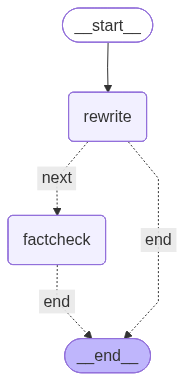

In [7]:
# A two-step content-editing pipeline: rewrite, then fact-check. Each step
# does ONE thing, with its own model and a cheap gate between steps.
EDITING_STEPS = [
    StepSpec(
        step_id="rewrite",
        system_prompt="[role]rewriter[/role] Improve clarity, preserve all numbers.",
        prompt_template="Draft:\n{user_input}",
        model="claude-sonnet-4-6",
        gate=length_gate(80, 600),
    ),
    StepSpec(
        step_id="factcheck",
        system_prompt=(
            "[role]factchecker[/role] Compare numbers across versions. "
            "Begin your reply with the single word 'verified' if every number "
            "matches, or 'discrepancy' if any differ — that one-word verdict "
            "is the gate's contract."
        ),
        # Reads BOTH the original draft and the rewrite — the information-
        # starvation guard. The rewrite can never hide the source.
        prompt_template=(
            "Original draft (source of truth):\n{user_input}\n\n"
            "Rewrite:\n{rewrite}\n\n"
            "Verify every number matches the original."
        ),
        model="claude-opus-4-6",
        # Anchored verdict: the reply must START with 'verified' or
        # 'discrepancy'. A substring gate would be wrong — 'unverified'
        # contains 'verified' and would wrongly pass.
        gate=starts_with_gate(["verified", "discrepancy"], name="verified-or-discrepancy"),
    ),
]

chain = build_chain_graph(EDITING_STEPS, _fake_llm)

show_graph(chain, alt="Prompt Chaining graph")

## A short trace printer

The trace should let a reader see the verdict quickly without drowning in a log dump: one line per attempt (a status marker, the step id, the gate name and reason), then the final output.

In [8]:
_MARK = {
    "success": "✓",
    "gate_failed": "✗",
    "retry_exhausted": "!",
    "llm_error": "E",
}


def print_trace(label: str, result: dict) -> None:
    """Short, readable audit of one chain run."""
    completed = result.get("completed", False)
    print(f"\n{label}")
    print("-" * len(label))
    print("completed     :", completed)
    if result.get("failure_reason"):
        print("failure_reason:", result["failure_reason"])
    print("per-step audit:")
    for run in result.get("runs", []):
        mark = _MARK.get(run["status"], "?")
        print(
            f"  {mark} {run['step_id']:10s} attempt {run['attempt']}  "
            f"gate=[{run['gate']}] -> {run['reason']}"
        )
        snippet = str(run["output"])[:80].replace("\n", " ")
        if snippet:
            print(f"      {snippet}")
    # Only a completed run has a meaningful final_output. On failure the
    # field holds the last SUCCESSFUL step's output (no reducer clears it),
    # which would be misleading to print as "the result".
    if completed:
        print("final_output  :", str(result.get("final_output") or "")[:80])

## Mock run 1: a clean two-step pipeline

The draft has a typo and the all-important "35%". Both steps pass their gate, and the fact-check verifies the numbers against the original draft.

In [9]:
# The raw draft has a typo ("byuer") and the all-important "35%".
draft = (
    "q3 gmv grew 35% YoY, driven by cat 4 (3C) and cat 7 (apparel). "
    "active byuer count up 18%."
)

result_ok = chain.invoke({"user_input": draft, "prior": {}})
# `completed` is derived here, after the run: the chain finished cleanly iff no
# node set a failure_reason. (A node can't know it's the last one, so the graph
# doesn't set this itself.)
result_ok["completed"] = not result_ok.get("failure_reason")
print_trace("Mock run 1: clean two-step pipeline", result_ok)


Mock run 1: clean two-step pipeline
-----------------------------------
completed     : True
per-step audit:
  ✓ rewrite    attempt 1  gate=[length[80-600]] -> length[80-600] ok
      In Q3, GMV expanded 35% YoY. The growth was led by 3C (category 4) and apparel (
  ✓ factcheck  attempt 1  gate=[verified-or-discrepancy] -> verified-or-discrepancy ok
      verified: numbers in the rewrite match the original draft (GMV 35%, active buyer
final_output  : verified: numbers in the rewrite match the original draft (GMV 35%, active buyer


## Mock run 2: a gate catches a bad step and retries

A stateful fake LLM returns a too-short draft on the first call (failing the length gate) and a full one on the second. The trace shows the first attempt rejected and the retry accepted — bad output never leaves the step.

In [10]:
# A gate that rejects the first attempt and accepts the second shows the
# retry loop working. We use a stateful fake LLM: the first call returns a
# too-short rewrite (fails the length gate), the second returns a full one.
_calls = {"n": 0}


def _flaky_llm(prompt: str, system_prompt: str, model: str) -> str:
    _calls["n"] += 1
    if _calls["n"] == 1:
        return "too short"  # < 80 chars, fails the gate
    return (
        "In Q3, GMV expanded 35% YoY, led by 3C (category 4) and apparel "
        "(category 7); active buyers increased 18% over the same period."
    )


retry_chain = build_chain_graph(
    [
        StepSpec(
            step_id="rewrite",
            system_prompt="[role]rewriter[/role] Improve clarity, preserve all numbers.",
            prompt_template="Draft:\n{user_input}",
            gate=length_gate(80, 600),
        )
    ],
    _flaky_llm,
)

result_retry = retry_chain.invoke({"user_input": "q3 gmv +35%, buyers +18%", "prior": {}})
result_retry["completed"] = not result_retry.get("failure_reason")
print_trace("Mock run 2: gate fails once, passes on retry", result_retry)


Mock run 2: gate fails once, passes on retry
--------------------------------------------
completed     : True
per-step audit:
  ✗ rewrite    attempt 1  gate=[length[80-600]] -> length[80-600] rejected (output length between 80 and 600 chars)
      too short
  ✓ rewrite    attempt 2  gate=[length[80-600]] -> length[80-600] ok
      In Q3, GMV expanded 35% YoY, led by 3C (category 4) and apparel (category 7); ac
final_output  : In Q3, GMV expanded 35% YoY, led by 3C (category 4) and apparel (category 7); ac


## Mock run 3: gate tyranny → retries exhausted

A gate that can never be satisfied. The chain retries up to `max_retries`, then gives up with a `failure_reason` and a `retry_exhausted` status — instead of looping forever. This is why gates should describe *tolerable* output, and why the retry budget is the safety valve when they don't.

In [11]:
# Gate tyranny: a gate that can never be satisfied. The chain retries up to
# max_retries, then gives up with a failure_reason instead of looping forever.
impossible = build_chain_graph(
    [
        StepSpec(
            step_id="rewrite",
            system_prompt="[role]rewriter[/role] Improve clarity, preserve all numbers.",
            prompt_template="Draft:\n{user_input}",
            gate=length_gate(5000, 6000, name="impossible"),  # fake reply is far shorter
        )
    ],
    _fake_llm,
)

result_tyranny = impossible.invoke({"user_input": draft, "prior": {}})
result_tyranny["completed"] = not result_tyranny.get("failure_reason")
print_trace("Mock run 3: gate tyranny -> retries exhausted", result_tyranny)


Mock run 3: gate tyranny -> retries exhausted
---------------------------------------------
completed     : False
failure_reason: step 'rewrite' gate 'impossible' failed after 3 attempts
per-step audit:
  ✗ rewrite    attempt 1  gate=[impossible] -> impossible rejected (output length between 5000 and 6000 chars)
      In Q3, GMV expanded 35% YoY. The growth was led by 3C (category 4) and apparel (
  ✗ rewrite    attempt 2  gate=[impossible] -> impossible rejected (output length between 5000 and 6000 chars)
      In Q3, GMV expanded 35% YoY. The growth was led by 3C (category 4) and apparel (
  ! rewrite    attempt 3  gate=[impossible] -> impossible rejected (output length between 5000 and 6000 chars)
      In Q3, GMV expanded 35% YoY. The growth was led by 3C (category 4) and apparel (


## Real backend

The model now does the actual editing work — rewriting, then fact-checking — while the gates stay deterministic and identical to the mock runs. The model is wrapped in a `real_llm_call` adapter so the chain code doesn't change at all.

Default: AI Studio + `ernie-5.1` (OpenAI-compatible). Configure in root `.env` — see [`.env.example`](../../../.env.example).

In [12]:
# Shared model loader — defaults to AI Studio + ernie-5.1 (OpenAI-compatible).
from model_config import get_model

model = get_model()


def real_llm_call(prompt: str, system_prompt: str, model_name: str) -> str:
    """Adapt the configured chat model to the chain's (prompt, system, model)
    call signature. The gates stay deterministic — only the text generation
    is delegated to the LLM."""
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": prompt},
    ]
    return model.invoke(messages).content

Model: ernie:ernie-5.1


In [13]:
if model:
    real_chain = build_chain_graph(EDITING_STEPS, real_llm_call)
    try:
        result_real = real_chain.invoke({"user_input": draft, "prior": {}})
        result_real["completed"] = not result_real.get("failure_reason")
        print_trace("Real run: two-step pipeline on a live model", result_real)
    except Exception as e:  # noqa: BLE001
        # The pipeline never raises into the notebook — a flaky model call
        # is reported, not propagated.
        print(f"Real run failed gracefully: {type(e).__name__}: {e}")
else:
    print("Skipping real run — no API key set. See .env.example.")


Real run: two-step pipeline on a live model
-------------------------------------------
completed     : True
per-step audit:
  ✓ rewrite    attempt 1  gate=[length[80-600]] -> length[80-600] ok
      In Q3, GMV grew 35% year-over-year (YoY), driven by Category 4 (3C) and Category
  ✓ factcheck  attempt 1  gate=[verified-or-discrepancy] -> verified-or-discrepancy ok
      verified
final_output  : verified


## Composing as a subgraph

The compiled chain is a first-class LangGraph object — it can be embedded as a node inside a larger agent graph. A parent agent might route only content-editing requests through the chain while handling everything else directly:

```python
parent = StateGraph(AgentState)
parent.add_node("editor_chain", chain)        # the compiled chain as one node
parent.add_node("react_agent", create_react_agent(model, tools))
parent.add_conditional_edges("react_agent", route_by_task, {
    "edit": "editor_chain",
    "other": END,
})
```

This is the same composability the [LCEL version](../langchain/tutorial.ipynb) gets from piping runnables — a chain is just another runnable you can drop into a bigger pipeline.

## What to remember

- **`StateGraph` makes the chain explicit** — `rewrite → factcheck` as visible nodes and edges you can debug in LangGraph Studio.
- **Gates are programmatic, not LLM calls.** A gate that calls a model is just another step. Keep them cheap: length, keys, schema.
- **`add_conditional_edges` implements early exit.** If a gate exhausts its retries, the graph jumps to `END` instead of running the doomed remainder.
- **Gate crash = reject, not pass.** Fail closed; a broken guardrail must never become an open door.
- **Every step sees all prior outputs.** Fact-check reads the *original* draft, not just the rewrite — that one wiring choice is the whole information-starvation guard.

## Further reading

- [LCEL version](../langchain/tutorial.ipynb) — the same Prompt Chaining pattern as LangChain runnables piped with `|`, using `.with_retry()` for the bounded gated retry
- [Parent pattern README](../README.md) — full design rationale, the two failure modes, gate-factory library, and verified engineering references (Aider's recursive-summary chain, Claude Code's PRA loop)
- [REFERENCE_IMPL.md](../../../REFERENCE_IMPL.md) — how to install `uv`, sync dependencies, launch JupyterLab, and run all tutorial notebooks
- [StateGraph reference](https://langchain-ai.github.io/langgraph/reference/graphs/) — the core LangGraph primitive for typed state machines with nodes, edges, and conditional routing
- [Anthropic · Building Effective Agents](https://www.anthropic.com/research/building-effective-agents) — prompt chaining as the simplest and most under-used agent pattern: a small number of well-defined steps with gates between them